In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *


In [2]:
# EJ = 3
# EC = EJ/4.6
# EL = EJ/21
EJ = 3
EC = EJ/4
EL = EJ/19.8

qubit_level = 40


def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]

    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [8.65]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 7.364666627721062e-07
             x: [ 8.658e+00]
           nit: 14
          nfev: 30
 final_simplex: (array([[ 8.658e+00],
                       [ 8.658e+00]]), array([ 7.365e-07,  2.114e-06]))
Optimal solution: [8.65765533]
Objective value: 7.364666627721062e-07


In [3]:

max_ol = 70
max_ql = 30
g = 0.25
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
# plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)


qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.035521989029085876
qbt freq at osc 1:	0.03551, 	diff to at osc ground -0.00001, 0.0202% diff
qbt freq at osc 2:	0.03551, 	diff to at osc ground -0.00002, 0.0439% diff
qbt freq at osc 3:	0.03550, 	diff to at osc ground -0.00003, 0.0711% diff
qbt freq at osc 4:	0.03549, 	diff to at osc ground -0.00004, 0.1022% diff
qbt freq at osc 5:	0.03547, 	diff to at osc ground -0.00005, 0.1373% diff
qbt freq at osc 6:	0.03546, 	diff to at osc ground -0.00006, 0.1771% diff
qbt freq at osc 7:	0.03544, 	diff to at osc ground -0.00008, 0.2226% diff
qbt freq at osc 8:	0.03542, 	diff to at osc ground -0.00010, 0.2764% diff
qbt freq at osc 9:	0.03540, 	diff to at osc ground -0.00012, 0.3466% diff
qbt freq at osc 10:	0.03535, 	diff to at osc ground -0.00017, 0.4817% diff
qbt freq at osc 11:	0.03553, 	diff to at osc ground 0.00001, 0.0149% diff
qbt freq at osc 12:	0.03540, 	diff to at osc ground -0.00012, 0.3439% d

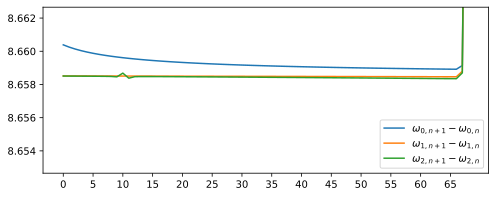

In [4]:
plt.figure(figsize = (8,3))
n_osc_lvls = max_ol-1
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::5])
plt.ylim(result.x[0]-0.005, result.x[0]+0.005)
# plt.ylim(7.9,7.92)
# plt.xticklabels([str(i) for i in range(n_osc_lvls)])
plt.legend(loc='lower right')

In [15]:
system.product_to_dressed[(2,13)],system.product_to_dressed[(2,12)],system.product_to_dressed[(2,11)],system.product_to_dressed[(2,10)],system.product_to_dressed[(2,9)]

(363, 333, 303, 272, 242)

In [14]:
dressed_ener(2,13)-dressed_ener(2,12),dressed_ener(2,12)-dressed_ener(2,11),dressed_ener(2,11)-dressed_ener(2,10),dressed_ener(2,10)-dressed_ener(2,9),dressed_ener(2,9)-dressed_ener(2,8),dressed_ener(2,8)-dressed_ener(2,7)

(8.658468556025724,
 8.658378138981263,
 8.65868273660675,
 8.65845913141382,
 8.658482975106907,
 8.658489565150283)

In [43]:
get_excitation_number_of_dressed_state(363),get_excitation_number_of_dressed_state(333),get_excitation_number_of_dressed_state(303),get_excitation_number_of_dressed_state(272),get_excitation_number_of_dressed_state(242)

((15.379235172609715+0j),
 (14.567031315227368+0j),
 (17.214480042915053+0j),
 (12.670297394447848+0j),
 (11.228340692693445+0j))

In [47]:
for ql in range(max_ql):
    for ol in range(max_ol):
        dressed_by_overlap = system.product_to_dressed[(ql,ol)]
        excitation_dressed = get_excitation_number_of_dressed_state(dressed_by_overlap)
        excitation_bare = ql+ol
        diff  = abs(excitation_bare - excitation_dressed)
        if diff >1:
            print(f"ql: {ql}, ol: {ol}, excitation diff: {diff}")

ql: 0, ol: 30, excitation diff: 1.0039153568971955
ql: 0, ol: 31, excitation diff: 1.0095853921192273
ql: 0, ol: 32, excitation diff: 1.0148719578549645
ql: 0, ol: 33, excitation diff: 1.0198039870412217
ql: 0, ol: 34, excitation diff: 1.024407748850365
ql: 0, ol: 35, excitation diff: 1.0287071460917971
ql: 0, ol: 36, excitation diff: 1.0327239732605804
ql: 0, ol: 37, excitation diff: 1.0364781416603677
ql: 0, ol: 38, excitation diff: 1.0399878761691426
ql: 0, ol: 39, excitation diff: 1.043269887820351
ql: 0, ol: 40, excitation diff: 1.0463395255329573
ql: 0, ol: 41, excitation diff: 1.0492109101130538
ql: 0, ol: 42, excitation diff: 1.0518970525913929
ql: 0, ol: 43, excitation diff: 1.0544099591495737
ql: 0, ol: 44, excitation diff: 1.0567607245164297
ql: 0, ol: 45, excitation diff: 1.058959615047499
ql: 0, ol: 46, excitation diff: 1.06101614277906
ql: 0, ol: 47, excitation diff: 1.06293913217565
ql: 0, ol: 48, excitation diff: 1.0647367791952433
ql: 0, ol: 49, excitation diff: 1.0664

In [6]:
system.hilbertspace.hamiltonian()

Quantum object: dims = [[30, 70], [30, 70]], shape = (2100, 2100), type = oper, isherm = True
Qobj data =
[[ -1.02304366   0.           0.         ...   0.           0.
    0.        ]
 [  0.           7.63461167   0.         ...   0.           0.
    0.        ]
 [  0.           0.          16.292267   ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ... 607.79918146   0.
    0.        ]
 [  0.           0.           0.         ...   0.         616.4568368
    0.        ]
 [  0.           0.           0.         ...   0.           0.
  625.11449213]]

In [23]:
def generate_excitation_array_1d(dims):
    arr = np.zeros(dims)
    for dim_index, dim_size in enumerate(dims):
        indices = [slice(None)] * len(dims)
        for level in range(dim_size):
            indices[dim_index] = level
            arr[tuple(indices)] += level
    flattened_arr = arr.flatten()
    return flattened_arr

# def generate_single_mapping(H_with_interaction_no_drive) -> np.ndarray:
#     """
#     The input should be in product basis
#     Using the exication-preserving method from PhysRevA.94.012347 to map product state to dressed state 

#     1) diagonalize the hamiltonian
#     2) find strips with constant excitation number
#     """

H_with_interaction_no_drive = system.hilbertspace.hamiltonian()


# 1)
evals, evecs = H_with_interaction_no_drive.eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)  # overlap_matrix[dressed_idx,product_idx] is the overlap. sum of overlap^2 is 1
# 2)
dressed_idx_to_total_excitation_number = {}
dims = H_with_interaction_no_drive.dims[0]
system_size = len(dims)


In [33]:

excitation_number_in_product_indices = generate_excitation_array_1d(dims)
def get_excitation_number_of_dressed_state(dressed_index):
    overlap_squared = overlap_matrix[dressed_index, :]**2
    return excitation_number_in_product_indices@overlap_squared

In [39]:
resi = []
for i in range(1000):
    excitation = get_excitation_number_of_dressed_state(i)
    int_excitation = round(excitation)
    resi.append(abs(excitation - int_excitation))

 /tmp/ipykernel_321570/2817025554.py: 4

(array([410., 115., 117.,  76.,  63.,  49.,  49.,  44.,  39.,  38.]),
 array([8.45829654e-05, 4.99272114e-02, 9.97698398e-02, 1.49612468e-01,
        1.99455097e-01, 2.49297725e-01, 2.99140353e-01, 3.48982982e-01,
        3.98825610e-01, 4.48668239e-01, 4.98510867e-01]),
 <BarContainer object of 10 artists>)

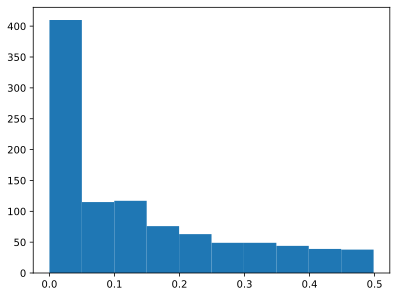

In [41]:
plt.hist(resi)

In [ ]:


product_state_names = []
def generate_product_states(current_state, ele_index):
    if ele_index == system_size:
        product_state_names.append(tuple(current_state))
        return
    
    for l in range(dims[ele_index]):
        current_state[ele_index] = l
        generate_product_states(current_state.copy(), ele_index + 1)

current_state = [0] * system_size
generate_product_states(current_state, 0)

total_dim = math.prod(dims)
dressed_indices_of_product_states = [None] * total_dim

# for every energy eigenstate, from the lowerst to the highest, find the product state
for dressed_index in range(len(evals)):
    max_position = (np.abs(overlap_matrix[dressed_index, :])).argmax()
    max_overlap = np.abs(overlap_matrix[dressed_index, max_position])
    overlap_matrix[:, max_position] = 0
    dressed_indices_of_product_states[int(max_position)] = dressed_index
    if (max_overlap**2 < OVERLAP_THRESHOLD):
        print(f'max overlap^2 {max_overlap**2} below threshold for dressed state {dressed_index} with eval {evals[dressed_index]}')
product_to_dressed = {}
for product, dressed in zip(product_state_names,dressed_indices_of_product_states):
    product_to_dressed[product] = dressed
return product_to_dressed
